**import** **tools**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes


**Get** **the** **data** **(diabetes dataset)**

In [4]:
diabetes = load_diabetes(as_frame=True, scaled=False)
df = diabetes.frame

#first five rows
display(df.head()) #better than print

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


**Print range of values for a column (e.g. 'bmi')** 

In [5]:
column_to_check = 'target'
min_val = df[column_to_check].min()
max_val = df[column_to_check].max()

print(f"Range of values for '{column_to_check}': From {min_val} to {max_val}")

Range of values for 'target': From 25.0 to 346.0


**Check for NaN values**

In [6]:
count_nan = df.isna().sum().sum()
print(count_nan)
if count_nan > 0:
    df = df.dropna()
    

0


**Histogram**

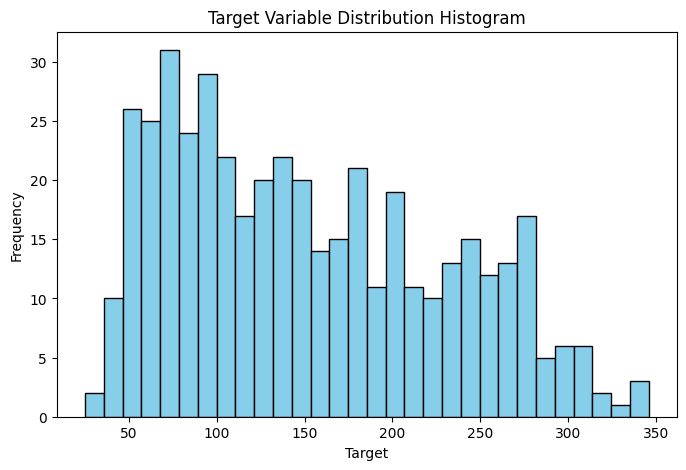

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['target'], bins=30, color='skyblue', edgecolor='black')
plt.title('Target Variable Distribution Histogram')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

**Data normalization using Min-Max scaling**

In [8]:
from sklearn.preprocessing import MinMaxScaler

#target as output, all the others inputs
X = df.drop('target', axis=1)
y = df[['target']]


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

#make them dataframe again
df_X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_y_scaled = pd.DataFrame(y_scaled, columns=['target'])

print(df_X_scaled.head(3))
print(df_y_scaled.head(3))


        age  sex       bmi        bp        s1        s2        s3        s4  \
0  0.666667  1.0  0.582645  0.549296  0.294118  0.256972  0.207792  0.282087   
1  0.483333  0.0  0.148760  0.352113  0.421569  0.306773  0.623377  0.141044   
2  0.883333  1.0  0.516529  0.436620  0.289216  0.258964  0.246753  0.282087   

         s5        s6  
0  0.562217  0.439394  
1  0.222437  0.166667  
2  0.496578  0.409091  
     target
0  0.392523
1  0.155763
2  0.361371


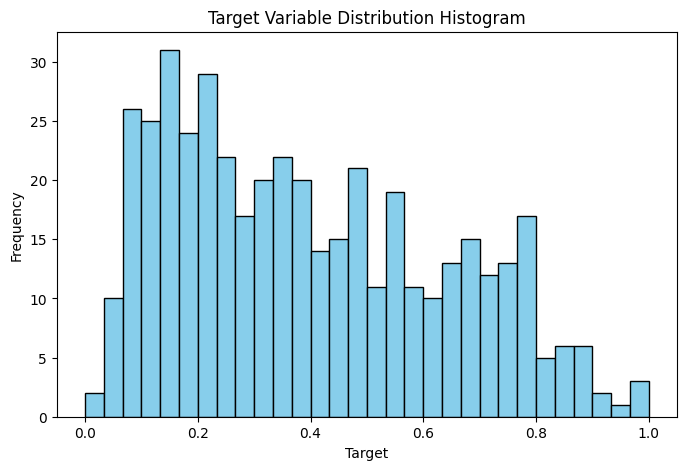

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_y_scaled['target'], bins=30, color='skyblue', edgecolor='black')
plt.title('Target Variable Distribution Histogram')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

**Definition of seeds**

In [10]:
seed = 42

**K-Fold**

In [11]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=6, shuffle=True, random_state=seed)

**Create a list to store the data** **//** **Append header row**

In [12]:

csv_data = []

csv_data.append(["Model", "Set", "Fold",
                 "Max_n", "RMSE_n", "MAE_n", "MAPE_n",
                 "Max", "RMSE", "MAE", "MAPE"])

**Setting Parameters for GPR // defining a function that train the model**

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import RandomizedSearchCV


def GPR(X_train, y_train,X_test): 
    gpr = GaussianProcessRegressor(normalize_y=False, random_state=seed)

    
    gpr_params = {
        "kernel": [
            RBF(length_scale=1.0), 
            Matern(length_scale=1.0, nu=1.5), 
            Matern(length_scale=1.0, nu=2.5),
            RationalQuadratic(length_scale=1.0)
        ],
        "alpha": [1e-10, 1e-5, 1e-2] 
}

    gpr_search = RandomizedSearchCV(gpr,gpr_params,n_iter=5,cv=3, scoring='neg_mean_squared_error',random_state=seed)
    gpr_search.fit(X_train, y_train)

    y_pred_train_n = gpr_search.predict(X_train)
    y_pred_test_n = gpr_search.predict(X_test)

    
    
    return y_pred_train_n, y_pred_test_n, gpr_search


**Setting Parameters for RF//defining a function that train the model**

In [14]:
from sklearn.ensemble import RandomForestRegressor

def RF(X_train, y_train, X_test):
    rf = RandomForestRegressor(random_state=seed)

    rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]   
    }

    rf_search = RandomizedSearchCV(estimator=rf, param_distributions=rf_params, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=seed, n_jobs=-1)
    
    rf_search.fit(X_train,y_train.values.ravel())
    
    y_pred_train_n = rf_search.predict(X_train) 
    y_pred_test_n = rf_search.predict(X_test)

    
    

    return y_pred_train_n , y_pred_test_n, rf_search


**Setting Parameters for SVR//defining a function that train the model**

In [15]:
from sklearn.svm import SVR

def SVR_algorithm(X_train, y_train, X_test):
    svr = SVR()
    param_dist = {
        'kernel': ['linear', 'rbf', 'poly'],
        'C': [0.1, 1, 10, 100],          
        'epsilon': [0.01, 0.1, 0.2, 0.5], 
        'gamma': ['scale', 'auto']        
    }
    svr_search = RandomizedSearchCV(
        estimator=svr,
        param_distributions=param_dist,
        n_iter=10,             # Πόσους συνδυασμούς να δοκιμάσει
        cv=3,                  # Cross validation μέσα στο train set
        scoring='neg_mean_squared_error',
        random_state=seed,
        n_jobs=-1
    )
    svr_search.fit(X_train,y_train.values.ravel())
    
    y_pred_train_n = svr_search.predict(X_train) 
    y_pred_test_n = svr_search.predict(X_test)

    
    
    return y_pred_train_n , y_pred_test_n, svr_search


**Setting Parameters for GBR//defining a function that train the model**

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

def GBR(X_train, y_train, X_test):
    gb = GradientBoostingRegressor(random_state=42)
    
    
    param_dist = {
        'n_estimators': [100, 200, 300],    
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5],             
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 1.0]             
    }
    
    # Ρύθμιση του RandomizedSearchCV
    gb_search = RandomizedSearchCV(
        estimator=gb,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    
    # Εκπαίδευση
    gb_search.fit(X_train, y_train.values.ravel())
    
    # Προβλέψεις
    y_pred_train_n = gb_search.predict(X_train)
    y_pred_test_n = gb_search.predict(X_test)

    return y_pred_train_n, y_pred_test_n, gb_search

**CHECK ERRORS FUNCTION**

In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error, mean_absolute_percentage_error

def check_errors(y_test_actual, y_pred_test):
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_test)) 
    mae = mean_absolute_error(y_test_actual, y_pred_test)          
    max_err = max_error(y_test_actual, y_pred_test) 
    mape = mean_absolute_percentage_error(y_test_actual, y_pred_test)
    return rmse, mae, max_err, mape

**Plot Actual VS PREDICTED**

In [18]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_true, y_pred, model_name, fold_num):
    plt.figure(figsize=(6, 6))
    
    # Scatter plot των τιμών
    plt.scatter(y_true, y_pred, color='blue', alpha=0.5, label=f'{model_name} predictions')
    
    # Η διαγώνιος γραμμή (Ideal)
    # Ξεκινάει από την ελάχιστη τιμή και φτάνει στη μέγιστη
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')
    
    plt.title(f'Actual vs Predicted - {model_name} (Fold {fold_num})')
    plt.xlabel('Actual Output')
    plt.ylabel('Predicted Output')
    plt.legend()
    plt.grid(True)
    
    # Αποθήκευση της εικόνας για την αναφορά (προαιρετικά)
    # plt.savefig(f"{model_name}_fold_{fold_num}_plot.png")
    plt.show()

**SHAP analysis function**

In [19]:
%pip install shap

import shap
import matplotlib.pyplot as plt
import os

def run_shap_analysis(model, X_test, fold_num, model_name):
    # Δημιουργία φακέλου για τις εικόνες αν δεν υπάρχει
    folder = f"shap_results_{model_name}"
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    # 1. Δημιουργία Explainer (χρησιμοποιούμε τον Explainer που ταιριάζει στο μοντέλο)
    # Για GBR/RF χρησιμοποιείται αυτόματα ο TreeExplainer
    explainer = shap.Explainer(model, X_test)
    shap_values = explainer(X_test)

    # --- 1. SHAP Summary Plot ---
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values, show=False)
    plt.title(f"Summary Plot - {model_name} - Fold {fold_num}")
    plt.savefig(f"{folder}/summary_fold_{fold_num}.png", bbox_inches='tight')
    plt.close()

    # --- 2. SHAP Waterfall Plots (για 2 παραδείγματα) ---
    # Επιλέγουμε το 1ο και το 2ο δείγμα του test set αυτού του fold
    indices_to_plot = [0, 1] 
    
    for i in indices_to_plot:
        plt.figure(figsize=(10, 6))
        # Το waterfall plot δείχνει πώς φτάσαμε από τη μέση τιμή στην πρόβλεψη
        shap.plots.waterfall(shap_values[i], show=False)
        plt.title(f"Waterfall Plot (Sample {i}) - Fold {fold_num}")
        plt.savefig(f"{folder}/waterfall_fold_{fold_num}_sample_{i}.png", bbox_inches='tight')
        plt.close()

    print(f"SHAP plots for Fold {fold_num} saved in folder: {folder}")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
def inverse(y_pred_train_n, y_pred_test_n):
    y_pred_train = scaler_y.inverse_transform(y_pred_train_n.reshape(-1, 1))
    y_pred_test = scaler_y.inverse_transform(y_pred_test_n.reshape(-1, 1))
    return y_pred_train, y_pred_test

def add_to_csv(csv_data, model_name,fold, set_type, errors_n, errors_actual):
    
    #unpacking of errors
    rmse_n, mae_n, max_n, mape_n = errors_n
    rmse, mae, max, mape = errors_actual

    row = [
        model_name,
        set_type,
        fold,
        f"{max_n:.2f}",    
        f"{rmse_n:.2f}",   
        f"{mae_n:.2f}",   
        f"{mape_n:.2f}",   
        f"{max:.2f}",    
        f"{rmse:.2f}",   
        f"{mae:.2f}",    
        f"{mape:.2f}"    
    ]
    csv_data.append(row)



#exoyme na kanoyme to csv file/ na vroyme ta error metrict gia ta train data 
fold_count = 1
for train_index, test_index in kf.split(df_X_scaled):
   
    X_train, X_test = df_X_scaled.iloc[train_index], df_X_scaled.iloc[test_index]
    y_train, y_test = df_y_scaled.iloc[train_index], df_y_scaled.iloc[test_index]

    #inverse the actual value
    y_test_actual = scaler_y.inverse_transform(y_test.values.reshape(-1,1))
    y_train_actual = scaler_y.inverse_transform(y_train.values.reshape(-1,1))
    
    print(f"Processing Fold: {fold_count}")
    
    
    # algorithm GPR, errors 
    print(f"TRAINING AND TESTING GAUSSIAN PROCESS REGRESSOR")
    y_pred_train_n_gpr, y_pred_test_n_gpr, gpr_search = GPR(X_train, y_train, X_test)
    #test results
    errors_n_gpr = check_errors(y_test.values, y_pred_test_n_gpr)
    y_pred_train_gpr, y_pred_test_gpr = inverse(y_pred_train_n_gpr, y_pred_test_n_gpr)
    errors_actual_gpr = check_errors(y_test_actual, y_pred_test_gpr)
    add_to_csv(csv_data, 'GPR', fold_count, 'test', errors_n_gpr, errors_actual_gpr)
    #train results
    errors_n_gpr_train = check_errors(y_train.values, y_pred_train_n_gpr)
    errors_actual_gpr_train = check_errors(y_train_actual, y_pred_train_gpr)
    add_to_csv(csv_data, 'GPR', fold_count, 'train', errors_n_gpr_train, errors_actual_gpr_train)


    #plot_actual_vs_predicted(y_test_actual, y_pred_test_gpr, "GPR", fold_count)
    
    #algorith RF, errors
    print(f"TRAINING AND TESTING RANDOM FORREST REGRESSOR")
    y_pred_train_n_rf, y_pred_test_n_rf, rf_search  = RF(X_train, y_train, X_test)
    errors_n_rf = check_errors(y_test.values, y_pred_test_n_rf)
    y_pred_train_rf, y_pred_test_rf = inverse(y_pred_train_n_rf, y_pred_test_n_rf)
    errors_actual_rf = check_errors(y_test_actual, y_pred_test_rf)
    add_to_csv(csv_data, 'RF', fold_count, 'test', errors_n_rf, errors_actual_rf)
    #train results
    errors_n_rf_train = check_errors(y_train.values, y_pred_train_n_rf)
    errors_actual_rf_train = check_errors(y_train_actual, y_pred_train_rf)
    add_to_csv(csv_data, 'RF', fold_count, 'train', errors_n_rf_train, errors_actual_rf_train)

    #plot_actual_vs_predicted(y_test_actual, y_pred_test_rf, "RF", fold_count)

    
    #algorithm SVR, errors
    print(f"TRAINING AND TESTING SUPPORT VECTOR REGRESSOR")
    y_pred_train_n_svr, y_pred_test_n_svr, svr_search = SVR_algorithm(X_train, y_train, X_test)
    errors_n_svr = check_errors(y_test.values, y_pred_test_n_svr)
    y_pred_train_svr, y_pred_test_svr = inverse(y_pred_train_n_svr, y_pred_test_n_svr)
    errors_actual_svr = check_errors(y_test_actual, y_pred_test_svr)
    add_to_csv(csv_data, 'SVR', fold_count, 'test', errors_n_svr, errors_actual_svr)
    #train results
    errors_n_svr_train = check_errors(y_train.values, y_pred_train_n_svr)
    errors_actual_svr_train = check_errors(y_train_actual, y_pred_train_svr)
    add_to_csv(csv_data, 'SVR', fold_count, 'train', errors_n_svr_train, errors_actual_svr_train)


    #plot_actual_vs_predicted(y_test_actual, y_pred_test_svr, "SVR", fold_count)

    #algorithm GBR, errors
    print(f"TRAINING AND TESTING GAUSSIAN BOOSTING REGRESSOR")
    y_pred_train_n_gbr, y_pred_test_n_gbr, gbr_search = GBR(X_train, y_train, X_test)
    errors_n_gbr = check_errors(y_test.values, y_pred_test_n_gbr)
    y_pred_train_gbr, y_pred_test_gbr = inverse(y_pred_train_n_gbr, y_pred_test_n_gbr)
    errors_actual_gbr = check_errors(y_test_actual, y_pred_test_gbr)
    add_to_csv(csv_data, 'GBR', fold_count, 'test', errors_n_gbr, errors_actual_gbr)
    #train results
    errors_n_gbr_train = check_errors(y_train.values, y_pred_train_n_gbr)
    errors_actual_gbr_train = check_errors(y_train_actual, y_pred_train_gbr)
    add_to_csv(csv_data, 'GBR', fold_count, 'train', errors_n_gbr_train, errors_actual_gbr_train)

    #plot_actual_vs_predicted(y_test_actual, y_pred_test_gbr, "GBR", fold_count)
    best_svr = svr_search.best_estimator_
    run_shap_analysis(best_svr, X_test, fold_count, "SVR")
    
    fold_count += 1


Processing Fold: 1
TRAINING AND TESTING GAUSSIAN PROCESS REGRESSOR


C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TRAINING AND TESTING RANDOM FORREST REGRESSOR
TRAINING AND TESTING SUPPORT VECTOR REGRESSOR
TRAINING AND TESTING GAUSSIAN BOOSTING REGRESSOR
SHAP plots for Fold 1 saved in folder: shap_results_SVR
Processing Fold: 2
TRAINING AND TESTING GAUSSIAN PROCESS REGRESSOR


C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TRAINING AND TESTING RANDOM FORREST REGRESSOR
TRAINING AND TESTING SUPPORT VECTOR REGRESSOR
TRAINING AND TESTING GAUSSIAN BOOSTING REGRESSOR
SHAP plots for Fold 2 saved in folder: shap_results_SVR
Processing Fold: 3
TRAINING AND TESTING GAUSSIAN PROCESS REGRESSOR


...

TRAINING AND TESTING RANDOM FORREST REGRESSOR
TRAINING AND TESTING SUPPORT VECTOR REGRESSOR
TRAINING AND TESTING GAUSSIAN BOOSTING REGRESSOR
SHAP plots for Fold 4 saved in folder: shap_results_SVR
Processing Fold: 5
TRAINING AND TESTING GAUSSIAN PROCESS REGRESSOR


C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TRAINING AND TESTING RANDOM FORREST REGRESSOR
TRAINING AND TESTING SUPPORT VECTOR REGRESSOR
TRAINING AND TESTING GAUSSIAN BOOSTING REGRESSOR
SHAP plots for Fold 5 saved in folder: shap_results_SVR
Processing Fold: 6
TRAINING AND TESTING GAUSSIAN PROCESS REGRESSOR


C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\giorg\AppData\Roaming\Python\Python314\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TRAINING AND TESTING RANDOM FORREST REGRESSOR
TRAINING AND TESTING SUPPORT VECTOR REGRESSOR
TRAINING AND TESTING GAUSSIAN BOOSTING REGRESSOR
SHAP plots for Fold 6 saved in folder: shap_results_SVR


**Making the file**

In [21]:
import csv



filename = "results.csv"


with open(filename, mode='w', newline='') as file:
    writer = csv.writer(file)
   
    writer.writerows(csv_data)

print(f"The file {filename} created succesfully!")


import pandas as pd 

df = pd.read_csv("results.csv")
df

The file results.csv created succesfully!


,Model,Set,Fold,Max_n,RMSE_n,MAE_n,MAPE_n,Max,RMSE,MAE,MAPE
0,GPR,test,1,0.47,0.16,0.13,5.300000e-01,150.72,52.47,41.63,0.36
1,GPR,train,1,0.47,0.16,0.13,4.370113e+12,151.89,50.79,40.80,0.36
2,RF,test,1,0.41,0.17,0.14,6.100000e-01,132.54,55.47,44.81,0.40
3,RF,train,1,0.31,0.11,0.09,2.581405e+12,100.46,34.19,27.36,0.24
4,SVR,test,1,0.46,0.17,0.14,5.800000e-01,147.30,55.95,45.02,0.38
5,SVR,train,1,0.50,0.17,0.13,4.633597e+12,159.53,53.60,43.11,0.38
6,GBR,test,1,0.40,0.17,0.14,6.500000e-01,129.72,54.47,45.30,0.42
7,GBR,train,1,0.40,0.15,0.12,3.449346e+12,127.64,47.52,39.97,0.37
8,GPR,test,2,0.62,0.19,0.15,5.600000e-01,198.46,60.50,46.61,0.38
9,GPR,train,2,0.44,0.12,0.09,4.510516e+12,141.30,37.61,28.45,0.26


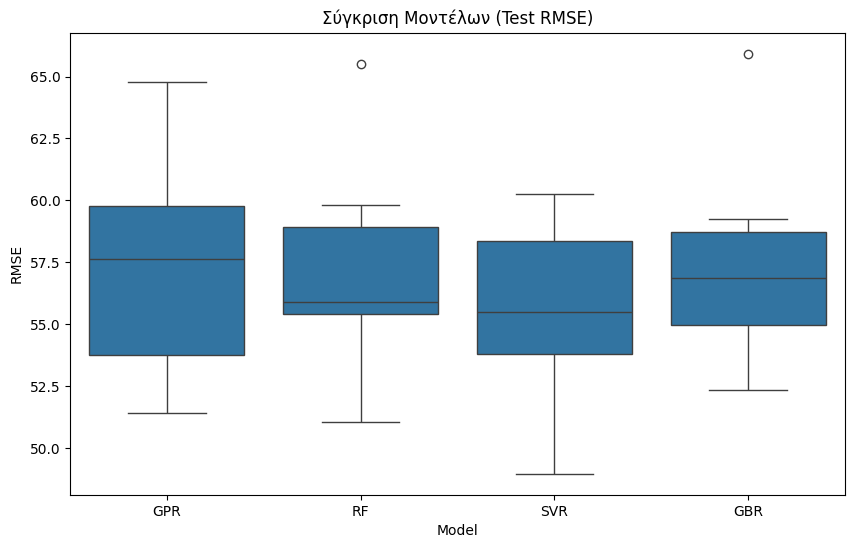

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Model', y='RMSE', data=df[df['Set'] == 'test'])
plt.title('Σύγκριση Μοντέλων (Test RMSE)')
plt.show()

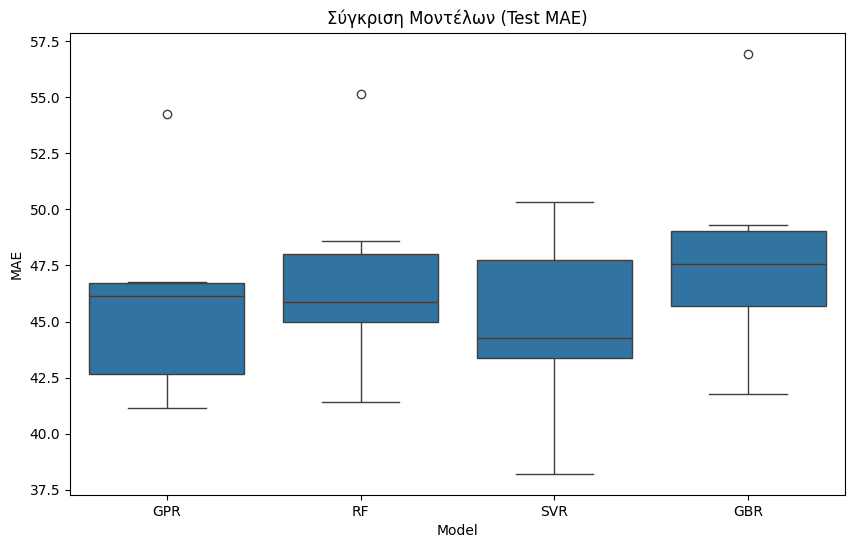

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Model', y='MAE', data=df[df['Set'] == 'test'])
plt.title('Σύγκριση Μοντέλων (Test MAE)')
plt.show()

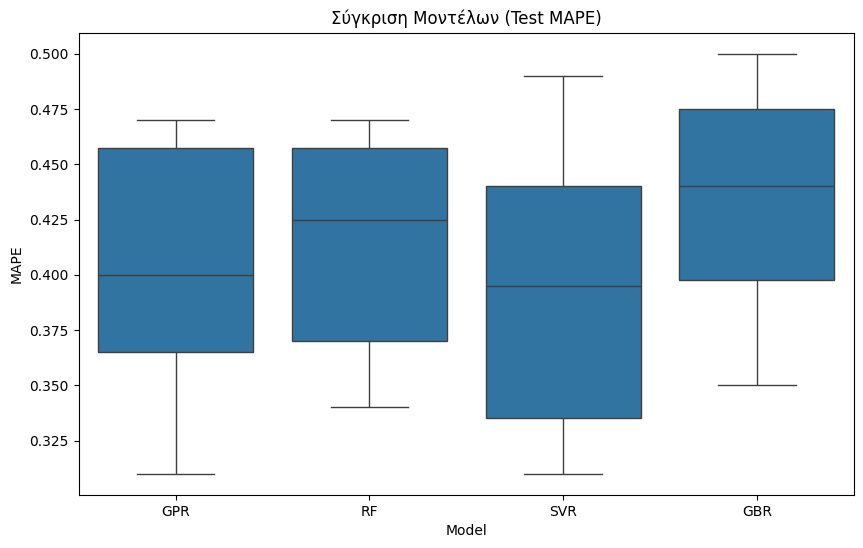

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Model', y='MAPE', data=df[df['Set'] == 'test'])
plt.title('Σύγκριση Μοντέλων (Test MAPE)')
plt.show()

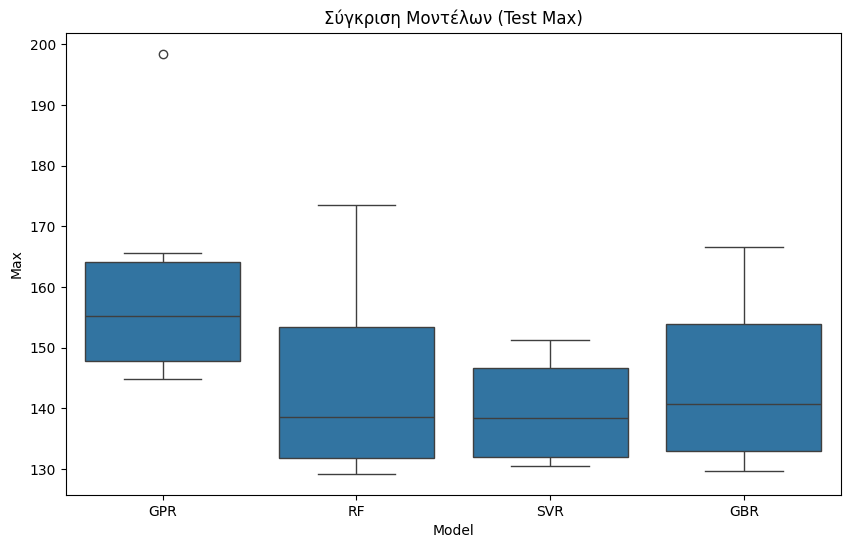

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Model', y='Max', data=df[df['Set'] == 'test'])
plt.title('Σύγκριση Μοντέλων (Test Max)')
plt.show()